Phase 1 — Shape, Types, and First Inspection

The first phase takes less than five minutes but gives you the structural skeleton of the dataset.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("boston.csv")

In [4]:
print(df.head())
print(f'Shape: {df.shape}')
print(df.dtypes) 
# print(df.tail())
# print(df.sample(5, random_state=0))

      CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD    TAX  \
0  0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296.0   
1  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242.0   
2  0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242.0   
3  0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222.0   
4  0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222.0   

   PTRATIO       B  LSTAT  MEDV  
0     15.3  396.90   4.98  24.0  
1     17.8  396.90   9.14  21.6  
2     17.8  392.83   4.03  34.7  
3     18.7  394.63   2.94  33.4  
4     18.7  396.90   5.33  36.2  
Shape: (506, 14)
CRIM       float64
ZN         float64
INDUS      float64
CHAS         int64
NOX        float64
RM         float64
AGE        float64
DIS        float64
RAD          int64
TAX        float64
PTRATIO    float64
B          float64
LSTAT      float64
MEDV       float64
dtype: object


In [5]:
# printing missing values

missing = df.isnull().sum()
print(missing)

CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64


In [6]:
# Duplicates

n_dupes = df.duplicated().sum()
print(n_dupes)
print(f'Duplicate rows: {n_dupes} ({100*n_dupes/len(df):.2f}%)')

0
Duplicate rows: 0 (0.00%)


Step 2: Deep EDA (Exploratory Data Analysis)

A. The target Variable (MEDV) Why: We need to know if the prices are skewed. If  they are, the model will strugle with expensive houses.


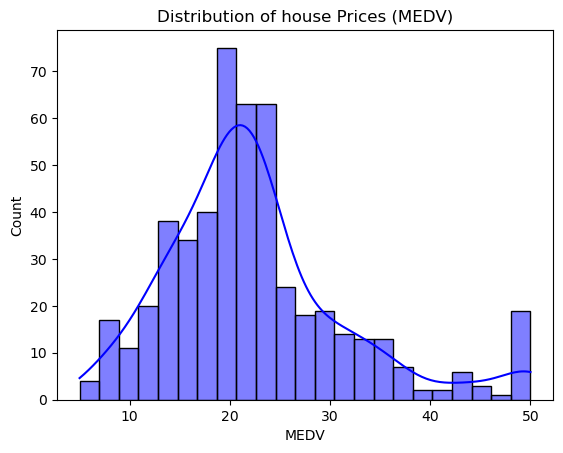

In [9]:
sns.histplot(df['MEDV'], kde = True, color = "blue")
plt.title("Distribution of house Prices (MEDV)")
plt.show()

Step 3: Checking the relationship between attributes or variables.

A Heatmap is used for easy display.
1 = highly related
0 = no reltion
-ve = inverse relation

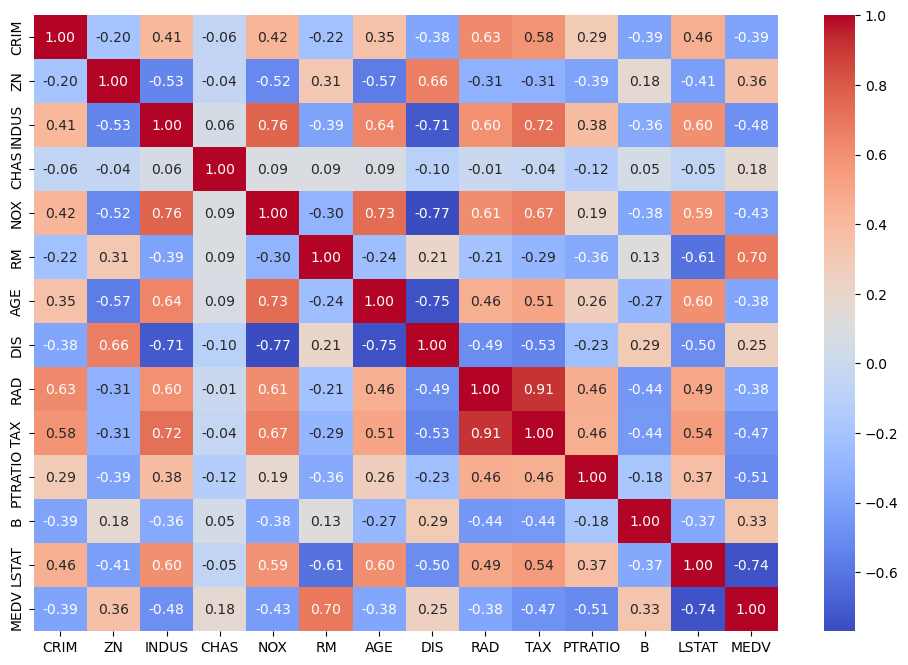

In [10]:
plt.figure(figsize = (12, 8))
sns.heatmap(df.corr(), annot = True, cmap = 'coolwarm', fmt = '.2f')
plt.show()

Plotting a regular plot of the most related and the least related feature to the target feature

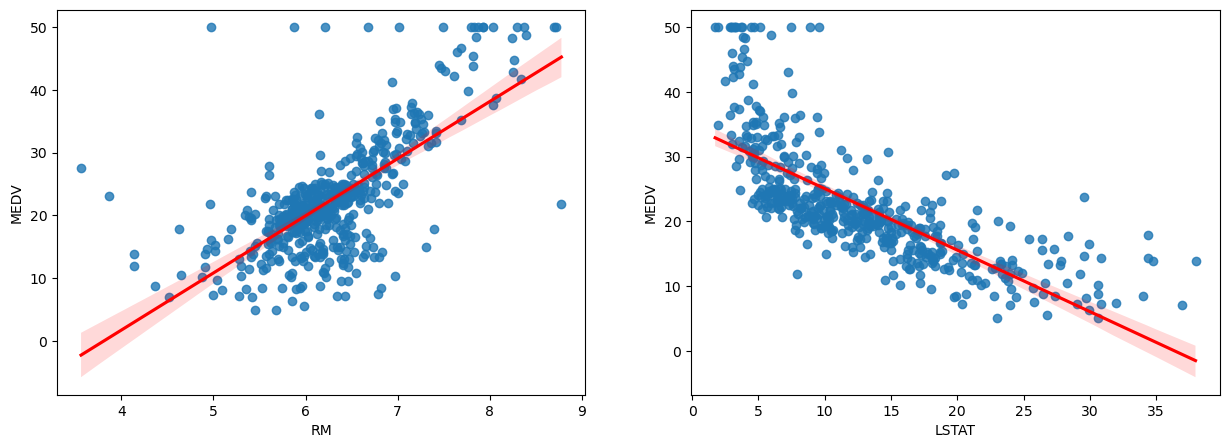

In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (15, 5))
sns.regplot(data = df, x = 'RM', y = 'MEDV', ax = ax1, line_kws = {'color' : 'red'})
sns.regplot(data = df, x = 'LSTAT', y = 'MEDV', ax = ax2, line_kws = {'color' : 'red'})
plt.show()

In [14]:
# kep only house prices that are below 50k cop

df = df[df['MEDV'] < 50]

In [15]:
df['CRIM'] = np.log1p(df['CRIM'])

In [20]:
df.skew().sort_values(ascending=False)

CHAS       3.747718
ZN         2.241578
CRIM       1.289256
RAD        1.014220
DIS        1.003954
LSTAT      0.907299
MEDV       0.775660
NOX        0.753539
TAX        0.680625
INDUS      0.321800
RM         0.174716
AGE       -0.587412
PTRATIO   -0.823673
B         -2.832125
dtype: float64

In [ ]:
df['CRIM'] = np.log1p(df['CRIM'])
df['LSTAT'] = np.log1p(df['LSTAT'])
df['TAX'] = np.log1p(df['TAX'])

In [23]:
y = np.log1p(df['MEDV'])

TRAINING THE MODEL

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler

In [33]:
# split to feature and target
X = df.drop('MEDV', axis = 1)
y = df['MEDV']

# Train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

# Scaling; ensure features like TAX and RM are on thesame scale
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Initializing and training
# we use a max_depth of 6 to prevent the model from memorizing (overfitting) the data
model = RandomForestRegressor(n_estimators = 100, max_depth = 6, random_state = 42)
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",6
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples a

In [34]:
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

preds = model.predict(X_test)

r2 = r2_score(y_test, preds)
mae = mean_absolute_error(y_test, preds)
rmse = np.sqrt(mean_squared_error(y_test, preds))

print(f"R2 Score: {r2:.4f}")
print(f"MAE: ${mae * 1000:,.2f}")
print(f"RMSE: ${rmse * 1000:,.2f}")

R2 Score: 0.8712
MAE: $1,900.81
RMSE: $2,564.92


In [35]:
print("Train R²:", model.score(X_train, y_train))
print("Test R²:", model.score(X_test, y_test))

Train R²: 0.950943654392281
Test R²: 0.871219203577708


In [37]:
import joblib

# Save model and scaler
joblib.dump(model, "house_price_model.pkl")
joblib.dump(scaler, "scaler.pkl")

print("Model saved successfully!")

Model saved successfully!


In [2]:
import gradio as gr
import numpy as np
import joblib

# Load model and scaler
model = joblib.load("house_price_model.pkl")
scaler = joblib.load("scaler.pkl")


/Users/louisa/miniconda3/envs/aiLearning311/lib/python3.11/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(
/Users/louisa/miniconda3/envs/aiLearning311/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


ImportError: cannot import name 'Sentinel' from 'typing_extensions' (/Users/louisa/miniconda3/envs/aiLearning311/lib/python3.11/site-packages/typing_extensions.py)

In [ ]:
def predict_house_price(
    CRIM,
    ZN,
    INDUS,
    CHAS,
    NOX,
    RM,
    AGE,
    DIS,
    RAD,
    TAX,
    PTRATIO,
    B,
    LSTAT
):

    # Apply same preprocessing used during training
    CRIM = np.log1p(CRIM)

    data = np.array([[
        CRIM,
        ZN,
        INDUS,
        CHAS,
        NOX,
        RM,
        AGE,
        DIS,
        RAD,
        TAX,
        PTRATIO,
        B,
        LSTAT
    ]])

    data_scaled = scaler.transform(data)

    prediction = model.predict(data_scaled)[0]

    return f"Estimated House Price: ${prediction * 1000:,.2f}"

In [1]:
demo = gr.Interface(
    fn=predict_house_price,

    inputs=[
        gr.Number(label="CRIM - Crime Rate"),
        gr.Number(label="ZN - Residential Land"),
        gr.Number(label="INDUS - Industrial Area"),
        gr.Radio([0, 1], label="CHAS - Borders Charles River"),
        gr.Number(label="NOX - Nitric Oxides Concentration"),
        gr.Number(label="RM - Average Rooms"),
        gr.Number(label="AGE - Age of Property"),
        gr.Number(label="DIS - Distance to Employment Centres"),
        gr.Number(label="RAD - Highway Accessibility"),
        gr.Number(label="TAX - Property Tax Rate"),
        gr.Number(label="PTRATIO - Pupil Teacher Ratio"),
        gr.Number(label="B - Demographic Statistic"),
        gr.Number(label="LSTAT - Lower Status Population (%)")
    ],

    outputs=gr.Textbox(label="Predicted House Value"),

    title="🏠 Boston Housing Price Predictor",

    description="""
    Enter housing information to estimate the median value
    of owner-occupied homes.
    """
)

demo.launch()

NameError: name 'gr' is not defined